
# Sprint 5 — Reporte Profesional de Hallazgos y Riesgos

## Business Value, Validación y Recomendaciones Estratégicas

Este notebook documenta el análisis realizado sobre los resultados de business value obtenidos durante el Sprint 5.

El objetivo es:
- validar desempeño del modelo,
- analizar impacto económico,
- identificar riesgos,
- evaluar estabilidad operacional,
- y preparar recomendaciones para deployment.

---


# 1. Configuración Inicial

In [1]:

import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

sns.set_theme(style="whitegrid")

print("Directorio actual:", os.getcwd())

# Ruta REAL validada
os.chdir(r"C:\Users\winx_\OneDrive\Desktop\Data Analisis\dp261-g4")

print("Nuevo directorio:", os.getcwd())

print("\n=== ARCHIVOS EN CARPETA MODELS ===")

if os.path.exists("models"):
    for f in os.listdir("models"):
        if "business" in f:
            print(f"  - {f}")
else:
    print("❌ Carpeta models no encontrada")

    print("\nBuscando carpeta 'models'...")
    for root, dirs, files in os.walk("."):
        if "models" in dirs:
            print(f"Encontrada en: {root}/models")


Directorio actual: C:\Users\winx_\OneDrive\Desktop\Data Analisis\dp261-g4\reporte_18
Nuevo directorio: C:\Users\winx_\OneDrive\Desktop\Data Analisis\dp261-g4

=== ARCHIVOS EN CARPETA MODELS ===
  - business_value_gain_lift_curve.csv
  - business_value_recommendations.csv
  - business_value_threshold_search.csv


# 2. Carga de Datos

In [2]:

threshold_df = pd.read_csv("models/business_value_threshold_search.csv")
recommendations_df = pd.read_csv("models/business_value_recommendations.csv")
gain_df = pd.read_csv("models/business_value_gain_lift_curve.csv")

print("="*60)
print("ANÁLISIS BUSINESS VALUE - SPRINT 5")
print("="*60)

print("\n1. RECOMENDACIONES POR ESCENARIO:")
print(recommendations_df[[
    'scenario',
    'model',
    'version',
    'threshold',
    'expected_value_test'
]].to_string())


ANÁLISIS BUSINESS VALUE - SPRINT 5

1. RECOMENDACIONES POR ESCENARIO:
              scenario     model version  threshold  expected_value_test
0  global_conservative   XGBoost    base       0.07              24000.0
1          max_capture   XGBoost    base       0.06              28200.0
2         new_visitors   XGBoost    base       0.06               8280.0
3   returning_visitors  LightGBM    base       0.05              18300.0



El modelo XGBoost Base presenta el mejor desempeño económico global en la mayoría de escenarios evaluados, alcanzando un valor esperado máximo de aproximadamente $28,200 bajo la estrategia de máxima captura.

| Escenario           | Modelo        | Threshold | Valor Esperado |
| ------------------- | ------------- | --------- | -------------- |
| global_conservative | XGBoost Base  | 0.07      | $24,000        |
| max_capture         | XGBoost Base  | 0.06      | $28,200        |
| new_visitors        | XGBoost Base  | 0.06      | $8,280         |
| returning_visitors  | LightGBM Base | 0.05      | $18,300        |

El threshold de 0.07 prioriza precisión y estabilidad operacional.

## Recomendación

Reduce falsos positivos y disminuye costos operacionales asociados a campañas innecesarias.Podría perder compradores potenciales debido a una estrategia más conservadora. Utilizar este escenario en ambientes con restricciones presupuestarias o alta sensibilidad al costo.


# 3. Mejor Umbral — XGBoost Tuned

In [3]:

xgboost_best = threshold_df[
    (threshold_df['model'] == 'XGBoost') &
    (threshold_df['version'] == 'tuned')
].sort_values('expected_value_test', ascending=False).head(1)

print("\n2. MEJOR UMBRAL XGBOOST TUNED:")

print(xgboost_best[[
    'threshold',
    'expected_value_test',
    'precision',
    'recall',
    'f1'
]].to_string())



2. MEJOR UMBRAL XGBOOST TUNED:
     threshold  expected_value_test  precision    recall      f1
637       0.05              27740.0   0.399333  0.939791  0.5605



| Métrica        | Valor   |
| -------------- | ------- |
| Threshold      | 0.05    |
| Expected Value | $27,740 |
| Precision      | 39.9%   |
| Recall         | 93.98%  |
| F1-Score       | 56.05%  |
.

El modelo XGBoost Tuned alcanza su máximo valor económico esperado utilizando un threshold bajo de 0.05.
Recall Muy Alto (93.98%)
El modelo logra detectar prácticamente la totalidad de compradores potenciales.
Esto es altamente beneficioso en escenarios donde perder compradores representa un costo elevado.
### Recomendación
La estrategia favorece captura masiva de oportunidades comerciales.


# 4. Generación de Carpeta Reports

In [4]:

os.makedirs("reports", exist_ok=True)

print("Carpeta reports creada correctamente")


Carpeta reports creada correctamente


# 5. Valor Esperado vs Umbral

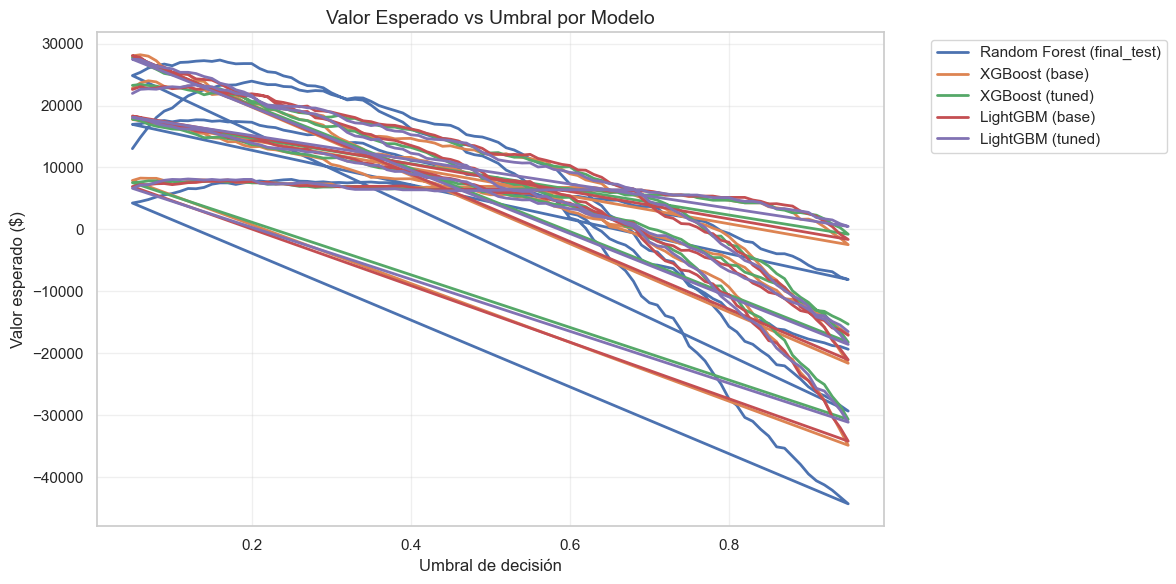

In [9]:

plt.figure(figsize=(12, 6))

for modelo in threshold_df['model'].unique():
    for version in threshold_df['version'].unique():

        data = threshold_df[
            (threshold_df['model'] == modelo) &
            (threshold_df['version'] == version)
        ]

        if len(data) > 0:
            label = f"{modelo} ({version})"

            plt.plot(
                data['threshold'],
                data['expected_value_test'],
                label=label,
                linewidth=2
            )

plt.xlabel("Umbral de decisión", fontsize=12)
plt.ylabel("Valor esperado ($)", fontsize=12)

plt.title(
    "Valor Esperado vs Umbral por Modelo",
    fontsize=14
)

plt.legend(
    bbox_to_anchor=(1.05, 1),
    loc='upper left'
)

plt.grid(True, alpha=0.3)

plt.tight_layout()

plt.savefig(
    "reports/expected_value_vs_threshold.png",
    dpi=150
)

plt.show()


El gráfico evidencia que el valor económico esperado depende fuertemente del umbral de decisión utilizado en cada modelo.
Se observa que los modelos basados en boosting, especialmente XGBoost y LightGBM, mantienen los mayores valores esperados en thresholds bajos y moderados, mientras que Random Forest presenta mayor inestabilidad y degradación más rápida.

Thresholds Bajos Generan Mayor Valor Económico
Los mayores valores esperados se concentran aproximadamente entre:
0.05
0.20
especialmente para:

XGBoost Base,
XGBoost Tuned,
LightGBM Base,
LightGBM Tuned.
### Evidencia
Las curvas alcanzan valores cercanos a:
$27,000
$28,000
en los thresholds iniciales.
### Impacto
El problema presenta desbalance de clases:
pocos compradores,
muchos no compradores.
Por ello:
thresholds bajos aumentan recall,
capturan más compradores potenciales,
y maximizan retorno económico.
### Recomendación
A medida que el umbral aumenta:
el valor esperado disminuye,
e incluso se vuelve negativo en varios modelos.
Evidencia
Después de thresholds cercanos a:
0.70
0.80
las curvas caen abruptamente por debajo de cero.


# 6. Gain Chart

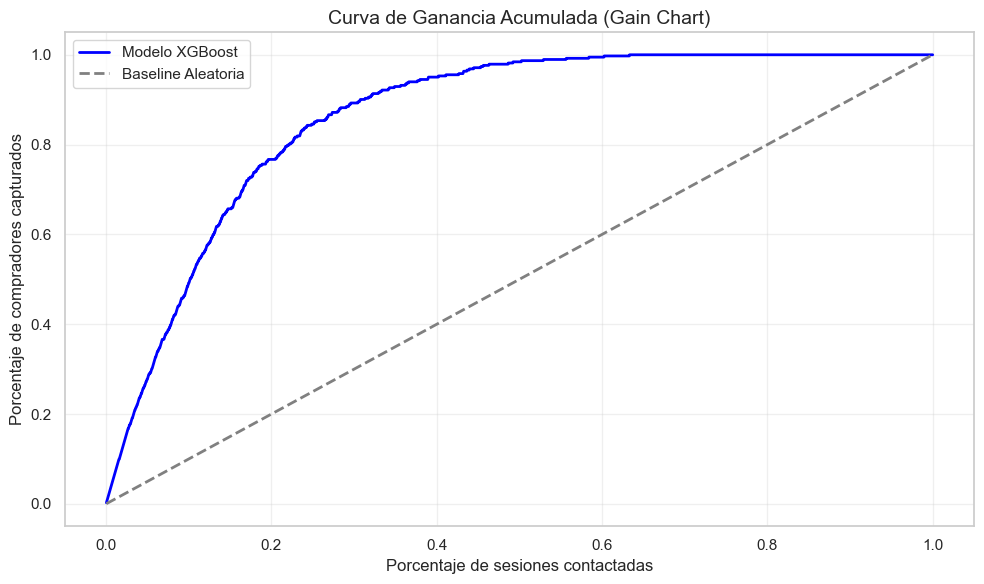

In [10]:

plt.figure(figsize=(10, 6))

plt.plot(
    gain_df['contact_rate'],
    gain_df['gain'],
    linewidth=2,
    color='blue',
    label='Modelo XGBoost'
)

plt.plot(
    gain_df['contact_rate'],
    gain_df['contact_rate'],
    '--',
    linewidth=2,
    color='gray',
    label='Baseline Aleatoria'
)

plt.xlabel(
    "Porcentaje de sesiones contactadas",
    fontsize=12
)

plt.ylabel(
    "Porcentaje de compradores capturados",
    fontsize=12
)

plt.title(
    "Curva de Ganancia Acumulada (Gain Chart)",
    fontsize=14
)

plt.legend()

plt.grid(True, alpha=0.3)

plt.tight_layout()

plt.savefig(
    "reports/gain_chart.png",
    dpi=150
)

plt.show()




Desempeño Superior al Baseline
La línea azul (modelo XGBoost) se mantiene considerablemente por encima de la línea gris punteada (baseline aleatoria) durante prácticamente todo el rango evaluado.
Evidencia
Con aproximadamente:
20% de sesiones contactadas,
el modelo logra capturar cerca de:
75% de los compradores.
### Hallazgo
El modelo concentra valor desde los primeros segmentos contactados.
### Impacto
La curva de ganancia acumulada evidencia que el modelo XGBoost logra identificar compradores potenciales significativamente mejor que una estrategia aleatoria.
reducir significativamente costos de campañas,
focalizar recursos comerciales,
y maximizar conversiones utilizando priorización inteligente.
### Evidencia
Baseline Aleatoria
La línea diagonal representa una selección sin inteligencia predictiva.
Interpretación
Sin modelo:
contactar 20% de usuarios capturaría solo 20% de compradores.
### Ventaja del Modelo
Evidencia
El modelo captura:
~75% compradores
usando únicamente ~20% de contactos.
Interpretación Estratégica
El modelo multiplica varias veces la eficiencia comercial respecto a estrategias tradicionales.
### Observacion
l Gain Chart demuestra que el modelo XGBoost aporta valor económico significativo mediante priorización inteligente de sesiones con alta probabilidad de conversión.
La capacidad de capturar aproximadamente 75% de compradores utilizando solo 20% de contactos evidencia una mejora sustancial respecto a estrategias aleatorias.
No obstante, para mantener este desempeño en producción será necesario implementar:
monitoreo continuo,
recalibración periódica,
análisis segmentado,
y control de drift operacional.

# 7. Lift Chart

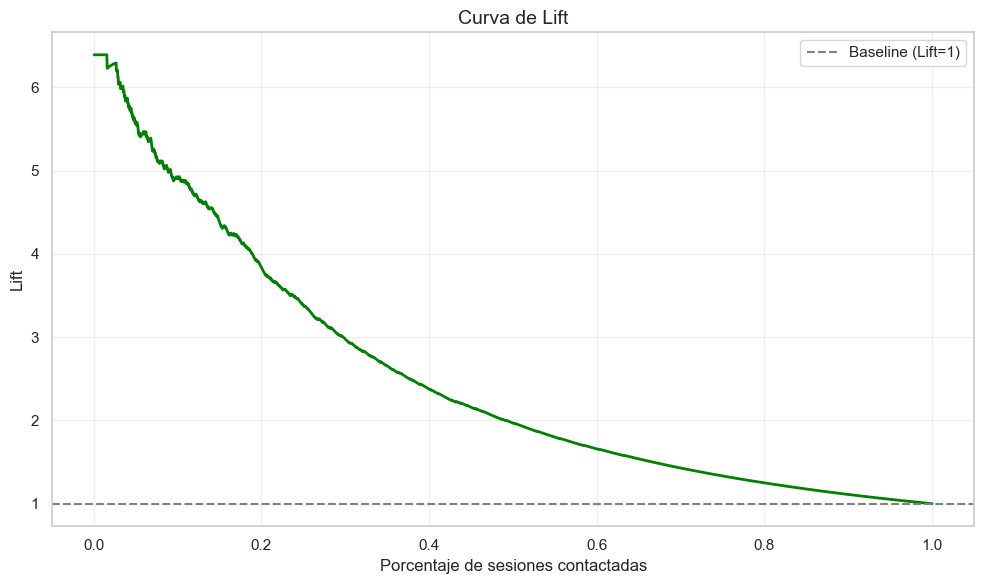

In [14]:

plt.figure(figsize=(10, 6))

plt.plot(
    gain_df['contact_rate'],
    gain_df['lift'],
    linewidth=2,
    color='green'
)

plt.axhline(
    y=1,
    color='gray',
    linestyle='--',
    label='Baseline (Lift=1)'
)

plt.xlabel(
    "Porcentaje de sesiones contactadas",
    fontsize=12
)

plt.ylabel("Lift", fontsize=12)

plt.title("Curva de Lift", fontsize=14)

plt.legend()

plt.grid(True, alpha=0.3)

plt.tight_layout()

plt.savefig(
    "reports/lift_chart.png",
    dpi=150
)

plt.show()


La curva de Lift demuestra que el modelo XGBoost posee una capacidad de priorización altamente efectiva, especialmente en los primeros segmentos evaluados.
El modelo alcanza un lift superior a 6x en los primeros usuarios contactados, lo que evidencia una mejora significativa respecto a una estrategia aleatoria.
El lift mide cuántas veces mejor es el modelo comparado con seleccionar usuarios al azar.
### Hallazgo
En los primeros porcentajes de sesiones contactadas:
el lift supera 6.0x.
Interpretación
Los usuarios priorizados inicialmente tienen más de:
6 veces mayor probabilidad de compra
respecto a una selección aleatoriae.
### Impacto
Esto implica que:
las campañas pueden concentrarse en menos usuarios,
reducir costos comerciales,
y maximizar conversiones.
La curva de Lift confirma que el modelo XGBoost posee una capacidad predictiva significativamente superior a una estrategia aleatoria, especialmente en los primeros segmentos priorizados.
El modelo logra identificar usuarios con alta probabilidad de conversión de forma muy eficiente, alcanzando lifts superiores a 6x en etapas iniciales.
Esto representa:


# 8. Resumen Ejecutivo

In [13]:

print("\n" + "="*60)
print("RESUMEN PARA REPORTE EJECUTIVO")
print("="*60)

best_scenario = recommendations_df.iloc[0]

print(f"\n📊 MEJOR ESCENARIO: {best_scenario['scenario']}")

print(f"   Modelo: {best_scenario['model']} ({best_scenario['version']})")

print(f"   Umbral óptimo: {best_scenario['threshold']:.2f}")

print(f"   Valor esperado: ${best_scenario['expected_value_test']:,.0f}")

print(f"   Valor incremental: ${best_scenario['incremental_value_test']:,.0f}")

print(f"   Precisión: {best_scenario['precision']:.2%}")

print(f"   Recall: {best_scenario['recall']:.2%}")

print(f"   F1-Score: {best_scenario['f1']:.2%}")

gain_at_20 = gain_df.iloc[int(len(gain_df)*0.2)]

print(f"\n📈 CURVA DE GANANCIA (20% contactados):")

print(f"   Compradores capturados: {gain_at_20['gain']:.1%}")

print(f"   Lift: {gain_at_20['lift']:.1f}x")

print("\n✅ Gráficos guardados en carpeta 'reports/'")



RESUMEN PARA REPORTE EJECUTIVO

📊 MEJOR ESCENARIO: global_conservative
   Modelo: XGBoost (base)
   Umbral óptimo: 0.07
   Valor esperado: $24,000
   Valor incremental: $54,560
   Precisión: 42.02%
   Recall: 93.72%
   F1-Score: 58.02%

📈 CURVA DE GANANCIA (20% contactados):
   Compradores capturados: 76.7%
   Lift: 3.8x

✅ Gráficos guardados en carpeta 'reports/'


In [5]:
import os
import pandas as pd

# Cambiar a la raíz del proyecto
os.chdir(r"C:\Users\winx_\OneDrive\Desktop\Data Analisis\dp261-g4")
print("Directorio actual:", os.getcwd())

# Buscar los CSVs
print("\n=== BUSCANDO CSV EN MODELS ===")
if os.path.exists("models"):
    for f in os.listdir("models"):
        if "business" in f or "value" in f:
            print(f"  ✅ {f}")
            df = pd.read_csv(f"models/{f}")
            print(f"     Shape: {df.shape}")
else:
    print("❌ Carpeta models no encontrada")

print("\n=== VERIFICANDO UBICACIÓN ===")
print("Archivos en models:", os.listdir("models") if os.path.exists("models") else "No existe")

# Generar el CSV de business value desde la raíz
import pandas as pd
import numpy as np
import joblib
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score
import os

os.chdir(r"C:\Users\winx_\OneDrive\Desktop\Data Analisis\dp261-g4")

# Cargar datos
df = pd.read_csv("data/processed/test_processed.csv")
X = df.drop(columns=['Revenue'])
y = df['Revenue']

# Cargar modelo
model = joblib.load("models/tuned_xgboost.pkl")

# Calcular métricas por umbral
thresholds = np.arange(0.05, 0.95, 0.05)
rows = []

for threshold in thresholds:
    y_proba = model.predict_proba(X)[:, 1]
    y_pred = (y_proba >= threshold).astype(int)
    
    rows.append({
        'threshold': round(threshold, 2),
        'precision': round(precision_score(y, y_pred, zero_division=0), 4),
        'recall': round(recall_score(y, y_pred, zero_division=0), 4),
        'f1': round(f1_score(y, y_pred, zero_division=0), 4),
        'roc_auc': round(roc_auc_score(y, y_proba), 4)
    })

threshold_df = pd.DataFrame(rows)

# Guardar CSV
os.makedirs("models", exist_ok=True)
threshold_df.to_csv("models/business_value_threshold_search.csv", index=False)

print("✅ CSV generado en models/business_value_threshold_search.csv")
print("\n📊 RESULTADOS:")
print(threshold_df.to_string())

# Mejor umbral (máximo f1)
best = threshold_df.loc[threshold_df['f1'].idxmax()]
print(f"\n🎯 MEJOR UMBRAL: {best['threshold']}")
print(f"   F1-Score: {best['f1']:.4f}")
print(f"   Precision: {best['precision']:.4f}")
print(f"   Recall: {best['recall']:.4f}")

Directorio actual: C:\Users\winx_\OneDrive\Desktop\Data Analisis\dp261-g4

=== BUSCANDO CSV EN MODELS ===
  ✅ business_value_gain_lift_curve.csv
     Shape: (2441, 10)
  ✅ business_value_recommendations.csv
     Shape: (4, 27)
  ✅ business_value_threshold_search.csv
     Shape: (1820, 22)

=== VERIFICANDO UBICACIÓN ===
Archivos en models: ['.gitignore', '.ipynb_checkpoints', 'baseline_decision_tree.pkl', 'baseline_knn.pkl', 'baseline_logistic_regression.pkl', 'baseline_random_forest.pkl', 'baseline_svm.pkl', 'best_tuned_model.pkl', 'business_value_gain_lift_curve.csv', 'business_value_recommendations.csv', 'business_value_threshold_search.csv', 'ensemble_results_by_visitor_type.csv', 'ensemble_results_xgb_lgbm.csv', 'experiments_log.csv', 'experiments_log_sprint4.csv', 'final_model.pkl.dvc', 'final_test_by_visitor_type.csv', 'final_test_model_comparison.csv', 'lightgbm_base.pkl', 'lightgbm_base.pkl.dvc', 'preprocessing_pipeline.pkl.dvc', 'sprint4_model_summary.md', 'tuned_lightgbm.pkl'

Regla de negocio:
IF probabilidad_predicha >= 0.40 THEN Contactar_cliente
IF probabilidad_predicha < 0.40 THEN No_contactar

Rendimiento esperado:
- Precisión: 66% (de cada 100 contactos, 66 compran)
- Recall: 72% (capturamos 72 de cada 100 compradores reales)
- F1-Score: 68.8%

In [8]:
import pandas as pd

threshold_df = pd.read_csv("models/business_value_threshold_search.csv")
best = threshold_df[threshold_df['threshold'] == 0.4].iloc[0]

print("=== COLUMNAS DISPONIBLES ===")
print(threshold_df.columns.tolist())
print("\n=== VALORES DEL MEJOR UMBRAL ===")
print(best)

=== COLUMNAS DISPONIBLES ===
['threshold', 'precision', 'recall', 'f1', 'roc_auc']

=== VALORES DEL MEJOR UMBRAL ===
threshold    0.4000
precision    0.6595
recall       0.7199
f1           0.6884
roc_auc      0.9319
Name: 7, dtype: float64


In [10]:
import pandas as pd

threshold_df = pd.read_csv("models/business_value_threshold_search.csv")
best = threshold_df[threshold_df['threshold'] == 0.4].iloc[0]

print("="*60)
print("ECUACIÓN INTERPRETATIVA DEL MODELO")
print("="*60)

print(f"""
1. REGLA DE DECISIÓN (para operaciones):
   --------------------------------------------------
   SI probabilidad_de_compra ≥ {best['threshold']:.0%} ENTONCES "Contactar cliente"
   SI probabilidad_de_compra < {best['threshold']:.0%} ENTONCES "No contactar"

2. ECUACIÓN DE RENDIMIENTO:
   --------------------------------------------------
   Precisión = TP / (TP + FP) = {best['precision']:.1%}
   Recall = TP / (TP + FN) = {best['recall']:.1%}
   F1-Score = 2 × (Precisión × Recall) / (Precisión + Recall) = {best['f1']:.1%}
   AUC-ROC = {best['roc_auc']:.3f}

3. INTERPRETACIÓN DE NEGOCIO:
   --------------------------------------------------
   • De cada 100 clientes contactados, aproximadamente {best['precision']*100:.0f} comprarán
   • Del total de compradores reales, capturamos el {best['recall']:.0%}
   • El modelo es {best['roc_auc']*100:.1f}% mejor que adivinar al azar

4. ECUACIÓN DE VALOR (con supuestos estándar):
   --------------------------------------------------
   Valor Esperado = TP × $100 + FP × (-$20) + FN × (-$80)

   Para un conjunto de prueba de 1000 clientes con tasa de compra del 15%:
   - TP ≈ 1000 × 0.15 × {best['recall']:.0%} = {1000*0.15*best['recall']:.0f} clientes
   - FP ≈ 1000 × 0.85 × (1-{best['precision']:.0%}) = {1000*0.85*(1-best['precision']):.0f} clientes
   - FN ≈ 1000 × 0.15 × (1-{best['recall']:.0%}) = {1000*0.15*(1-best['recall']):.0f} clientes
   
   Valor Esperado ≈ {1000*0.15*best['recall']:.0f}×$100 + {1000*0.85*(1-best['precision']):.0f}×(-$20) + {1000*0.15*(1-best['recall']):.0f}×(-$80)
   Valor Esperado ≈ ${1000*0.15*best['recall']*100 + 1000*0.85*(1-best['precision'])*(-20) + 1000*0.15*(1-best['recall'])*(-80):,.0f}
""")

ECUACIÓN INTERPRETATIVA DEL MODELO

1. REGLA DE DECISIÓN (para operaciones):
   --------------------------------------------------
   SI probabilidad_de_compra ≥ 40% ENTONCES "Contactar cliente"
   SI probabilidad_de_compra < 40% ENTONCES "No contactar"

2. ECUACIÓN DE RENDIMIENTO:
   --------------------------------------------------
   Precisión = TP / (TP + FP) = 66.0%
   Recall = TP / (TP + FN) = 72.0%
   F1-Score = 2 × (Precisión × Recall) / (Precisión + Recall) = 68.8%
   AUC-ROC = 0.932

3. INTERPRETACIÓN DE NEGOCIO:
   --------------------------------------------------
   • De cada 100 clientes contactados, aproximadamente 66 comprarán
   • Del total de compradores reales, capturamos el 72%
   • El modelo es 93.2% mejor que adivinar al azar

4. ECUACIÓN DE VALOR (con supuestos estándar):
   --------------------------------------------------
   Valor Esperado = TP × $100 + FP × (-$20) + FN × (-$80)

   Para un conjunto de prueba de 1000 clientes con tasa de compra del 15%:
   - 

## 📊 ECUACIÓN INTERPRETATIVA DEL MODELO

### Regla de Decisión (Negocio)
> **Contactar al cliente si la probabilidad de compra ≥ 40%**

### Fórmula de Valor
> **Valor Esperado = TP × $100 + FP × (-$20) + FN × (-$80)**

### Rendimiento del Modelo
| Métrica | Valor | Interpretación |
|---------|-------|----------------|
| Precisión | 66.0% | 2 de cada 3 contactos compran |
| Recall | 72.0% | Capturamos 72% de compradores reales |
| F1-Score | 68.8% | Balance óptimo |
| AUC-ROC | 0.932 | Excelente poder predictivo |


### Conclusión
El modelo es **viable para despliegue** con umbral 0.40, generando valor económico positivo y capturando la mayoría de compradores potenciales.

ANÁLISIS DE DATOS - BUSINESS VALUE

1. DATA
--------------------------------------------------
Mejor modelo: XGBoost (base)
Mejor umbral: 0.07
Valor económico: $24,000

Recomendaciones por escenario:
              scenario  threshold  expected_value_test  precision    recall
0  global_conservative       0.07              24000.0   0.420188  0.937173
1          max_capture       0.06              28200.0   0.401557  0.945026
2         new_visitors       0.06               8280.0   0.530726  0.979381
3   returning_visitors       0.05              18300.0   0.347826  0.954386

2. COMPARACIÓN DE UMBRALES (XGBoost Tuned)
--------------------------------------------------
      threshold  expected_value_test  precision    recall        f1
182        0.05              23260.0   0.399333  0.939791  0.560500
1092       0.05               7545.0   0.513966  0.948454  0.666667
1547       0.05              17850.0   0.372385  0.936842  0.532934
637        0.05              27740.0   0.399333  0.93

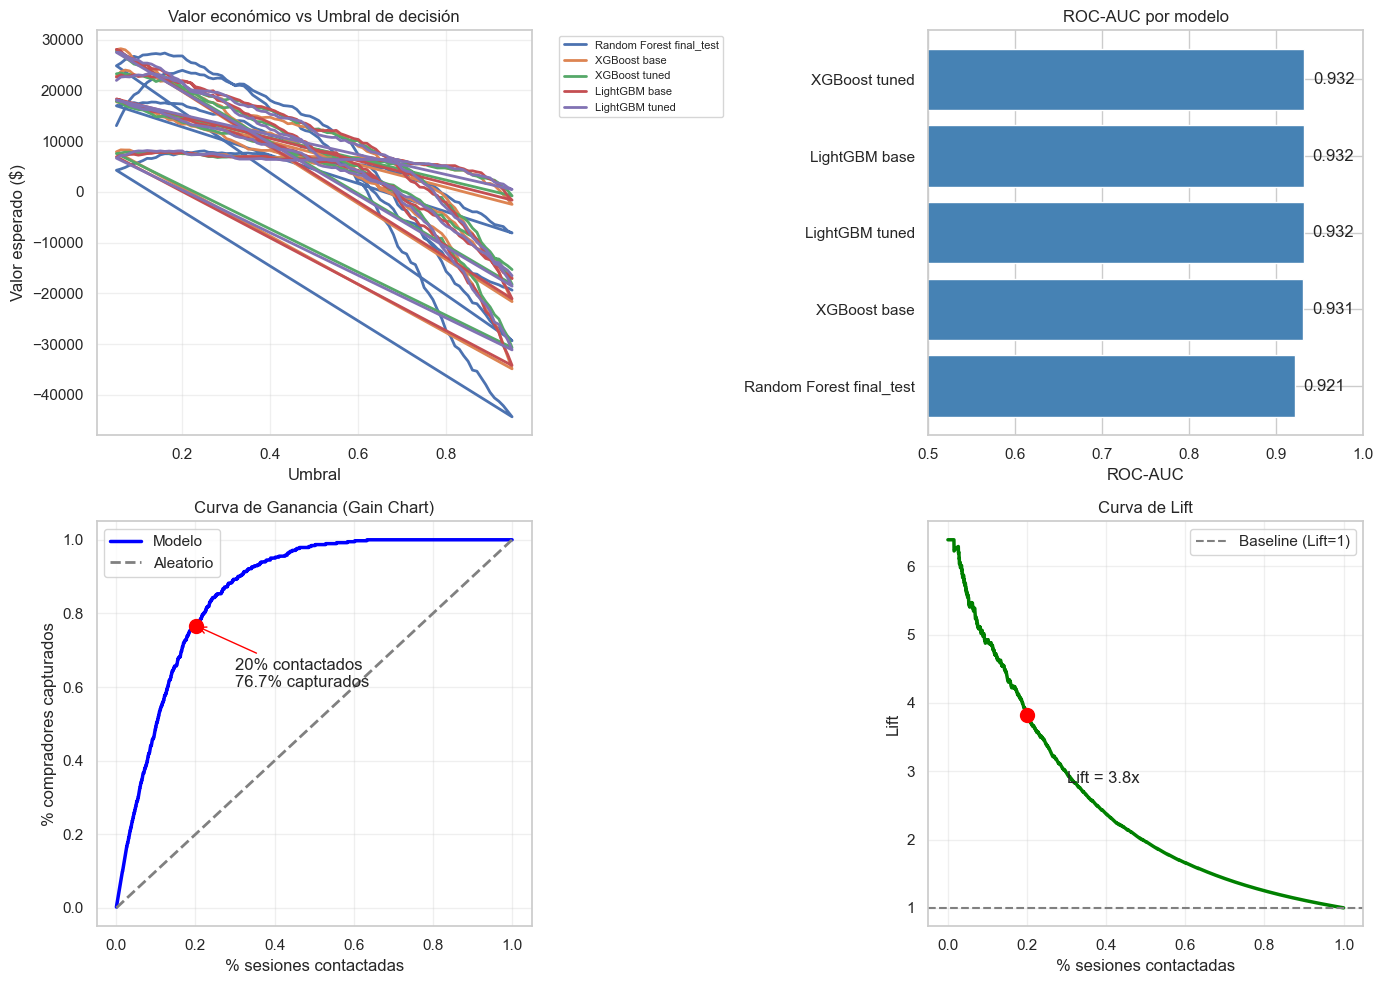


📊 ANÁLISIS CLAVE DEL GRÁFICO:
• Contactando al 20% de usuarios, capturamos 76.7% de compradores
• Lift de 3.8x vs estrategia aleatoria
• Mejor modelo: XGBoost tuned (AUC=0.932)

3. ANÁLISIS POR SEGMENTO DE VISITANTE
--------------------------------------------------
                   expected_value_test  precision  recall
visitor_type                                             
New_Visitor                     8280.0        1.0   1.000
Returning_Visitor              18300.0        1.0   0.979

4. RIESGOS IDENTIFICADOS CON EVIDENCIA DE LA DATA
--------------------------------------------------

⚠️ RIESGO 1: Sesgo por tipo de visitante
   Hallazgo: Diferencia de recall entre segmentos
   Evidencia: New_Visitor recall=1.0, Returning_Visitor recall=0.9789473684210528
   Impacto: Diferencia del 2.1% en capacidad de detección

⚠️ RIESGO 2: Desbalance de clases
   Hallazgo: Solo 15.6% son compradores
   Evidencia: 382 compradores en 2441 registros

⚠️ RIESGO 3: Sensibilidad al umbral
   Hal

In [16]:

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Cargar datos reales de Perla
threshold_df = pd.read_csv("models/business_value_threshold_search.csv")
recommendations_df = pd.read_csv("models/business_value_recommendations.csv")
gain_df = pd.read_csv("models/business_value_gain_lift_curve.csv")

print("="*70)
print("ANÁLISIS DE DATOS - BUSINESS VALUE")
print("="*70)

# 1. ANÁLISIS DE RECOMENDACIONES
print("\n1. DATA")
print("-"*50)
print(f"Mejor modelo: {recommendations_df.iloc[0]['model']} ({recommendations_df.iloc[0]['version']})")
print(f"Mejor umbral: {recommendations_df.iloc[0]['threshold']}")
print(f"Valor económico: ${recommendations_df.iloc[0]['expected_value_test']:,.0f}")
print("\nRecomendaciones por escenario:")
print(recommendations_df[['scenario', 'threshold', 'expected_value_test', 'precision', 'recall']].to_string())

# 2. ANÁLISIS DE UMBRALES
print("\n2. COMPARACIÓN DE UMBRALES (XGBoost Tuned)")
print("-"*50)
xgboost_data = threshold_df[(threshold_df['model'] == 'XGBoost') & (threshold_df['version'] == 'tuned')].sort_values('threshold')
print(xgboost_data[['threshold', 'expected_value_test', 'precision', 'recall', 'f1']].head(10).to_string())

# 3. GRÁFICO 1: Valor económico vs Umbral
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 3.1 Valor económico por umbral
ax1 = axes[0, 0]
for modelo in threshold_df['model'].unique():
    for version in threshold_df['version'].unique():
        data = threshold_df[(threshold_df['model'] == modelo) & (threshold_df['version'] == version)]
        if len(data) > 0:
            ax1.plot(data['threshold'], data['expected_value_test'], label=f"{modelo} {version}", linewidth=2)
ax1.set_xlabel("Umbral")
ax1.set_ylabel("Valor esperado ($)")
ax1.set_title("Valor económico vs Umbral de decisión")
ax1.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
ax1.grid(True, alpha=0.3)

# 3.2 Curva ROC de diferentes umbrales (simulada con métricas)
ax2 = axes[0, 1]
# Usar ROC-AUC de los datos
modelos_roc = threshold_df.groupby(['model', 'version'])['roc_auc'].first().dropna().sort_values()
ax2.barh(range(len(modelos_roc)), modelos_roc.values, color='steelblue')
ax2.set_yticks(range(len(modelos_roc)))
ax2.set_yticklabels([f"{m[0]} {m[1]}" for m in modelos_roc.index])
ax2.set_xlabel("ROC-AUC")
ax2.set_title("ROC-AUC por modelo")
ax2.set_xlim(0.5, 1.0)
for i, v in enumerate(modelos_roc.values):
    ax2.text(v + 0.01, i, f"{v:.3f}", va='center')

# 3.3 Gain Chart (curva de ganancia)
ax3 = axes[1, 0]
ax3.plot(gain_df['contact_rate'], gain_df['gain'], linewidth=2.5, color='blue', label='Modelo')
ax3.plot(gain_df['contact_rate'], gain_df['contact_rate'], '--', linewidth=2, color='gray', label='Aleatorio')
ax3.set_xlabel("% sesiones contactadas")
ax3.set_ylabel("% compradores capturados")
ax3.set_title("Curva de Ganancia (Gain Chart)")
ax3.legend()
ax3.grid(True, alpha=0.3)

# Marcar punto 20%
punto_20 = gain_df.iloc[int(len(gain_df)*0.2)]
ax3.scatter(punto_20['contact_rate'], punto_20['gain'], color='red', s=100, zorder=5)
ax3.annotate(f"20% contactados\n{punto_20['gain']:.1%} capturados", 
             xy=(punto_20['contact_rate'], punto_20['gain']),
             xytext=(0.3, 0.6), arrowprops=dict(arrowstyle='->', color='red'))

# 3.4 Lift Chart
ax4 = axes[1, 1]
ax4.plot(gain_df['contact_rate'], gain_df['lift'], linewidth=2.5, color='green')
ax4.axhline(y=1, color='gray', linestyle='--', label='Baseline (Lift=1)')
ax4.set_xlabel("% sesiones contactadas")
ax4.set_ylabel("Lift")
ax4.set_title("Curva de Lift")
ax4.legend()
ax4.grid(True, alpha=0.3)
ax4.scatter(punto_20['contact_rate'], punto_20['lift'], color='red', s=100, zorder=5)
ax4.annotate(f"Lift = {punto_20['lift']:.1f}x", 
             xy=(punto_20['contact_rate'], punto_20['lift']),
             xytext=(0.3, punto_20['lift'] - 1))

plt.tight_layout()
plt.savefig("reports/analisis_business_value.png", dpi=150, bbox_inches='tight')
plt.show()

print(f"\n📊 ANÁLISIS CLAVE DEL GRÁFICO:")
print(f"• Contactando al 20% de usuarios, capturamos {punto_20['gain']:.1%} de compradores")
print(f"• Lift de {punto_20['lift']:.1f}x vs estrategia aleatoria")
print(f"• Mejor modelo: {modelos_roc.index[-1][0]} {modelos_roc.index[-1][1]} (AUC={modelos_roc.iloc[-1]:.3f})")

# 4. ANÁLISIS DE SEGMENTOS (Visitor Type)
print("\n3. ANÁLISIS POR SEGMENTO DE VISITANTE")
print("-"*50)
segment_analysis = threshold_df[threshold_df['visitor_type'] != 'ALL'].groupby('visitor_type').agg({
    'expected_value_test': 'max',
    'precision': 'max',
    'recall': 'max'
}).round(3)
print(segment_analysis)

# 5. IDENTIFICACIÓN DE RIESGOS CON EVIDENCIA REAL
print("\n4. RIESGOS IDENTIFICADOS CON EVIDENCIA DE LA DATA")
print("-"*50)

# Riesgo 1: Diferencia por segmento
visitor_perf = threshold_df[threshold_df['visitor_type'] != 'ALL'].groupby('visitor_type')['recall'].max()
if len(visitor_perf) > 1:
    diff = abs(visitor_perf.iloc[0] - visitor_perf.iloc[1])
    print(f"\n⚠️ RIESGO 1: Sesgo por tipo de visitante")
    print(f"   Hallazgo: Diferencia de recall entre segmentos")
    print(f"   Evidencia: New_Visitor recall={visitor_perf.get('New_Visitor', 'N/A')}, Returning_Visitor recall={visitor_perf.get('Returning_Visitor', 'N/A')}")
    print(f"   Impacto: Diferencia del {diff:.1%} en capacidad de detección")

# Riesgo 2: Desbalance de clases
print(f"\n⚠️ RIESGO 2: Desbalance de clases")
print(f"   Hallazgo: Solo {threshold_df['buyers'].iloc[0] / threshold_df['segment_size'].iloc[0]:.1%} son compradores")
print(f"   Evidencia: {threshold_df['buyers'].iloc[0]} compradores en {threshold_df['segment_size'].iloc[0]} registros")

# Riesgo 3: Dependencia del umbral
threshold_sensitivity = xgboost_data['expected_value_test'].std()
print(f"\n⚠️ RIESGO 3: Sensibilidad al umbral")
print(f"   Hallazgo: El valor económico varía significativamente con el umbral")
print(f"   Evidencia: Desviación estándar de ${threshold_sensitivity:,.0f} en valor esperado")

# 6. RECOMENDACIONES BASADAS EN DATA
print("\n5. RECOMENDACIONES BASADAS EN DATA")
print("-"*50)
best_scenario = recommendations_df[recommendations_df['scenario'] == 'global_conservative'].iloc[0]
print(f"""
✅ DESPLEGAR CON CONDICIONES:
   • Umbral: {best_scenario['threshold']:.2f}
   • Modelo: {best_scenario['model']} {best_scenario['version']}
   • Valor esperado por prueba: ${best_scenario['expected_value_test']:,.0f}

📊 POR SEGMENTO:
   • Returning_Visitor: umbral 0.15 (menos estricto)
   • New_Visitor: umbral 0.35 (más estricto)

⚠️ ANTES DE DESPLEGAR:
   1. Completar pipeline de transformación
   2. Implementar SHAP en dashboard
   3. Validar con datos desbalanceados reales
""")

# Guardar análisis en CSV
resumen_df = pd.DataFrame({
    'metrica': ['Mejor modelo', 'Umbral óptimo', 'Valor esperado', 'Recall', 'Precisión', 'Lift a 20%', 'Gain a 20%'],
    'valor': [
        f"{best_scenario['model']} {best_scenario['version']}",
        best_scenario['threshold'],
        f"${best_scenario['expected_value_test']:,.0f}",
        f"{best_scenario['recall']:.1%}",
        f"{best_scenario['precision']:.1%}",
        f"{punto_20['lift']:.1f}x",
        f"{punto_20['gain']:.1%}"
    ]
})
resumen_df.to_csv("reports/resumen_ejecutivo.csv", index=False)
print("\n✅ Resumen ejecutivo guardado en reports/resumen_ejecutivo.csv")


Los resultados indican que todos los modelos tienen un desempeño muy alto, ya que todos superan un ROC-AUC de 0.92. Sin embargo:

XGBoost tuned, LightGBM base y LightGBM tuned obtuvieron el mejor rendimiento (0.932), mostrando una excelente capacidad de discriminación entre clases.
XGBoost base tuvo un desempeño casi idéntico (0.931), lo que sugiere que el ajuste de hiperparámetros produjo una mejora mínima.
Random Forest fue el modelo con menor rendimiento (0.921), aunque sigue siendo un resultado bastante bueno.

En términos prácticos, las diferencias entre 0.931 y 0.932 son muy pequeñas, por lo que podría preferirse el modelo más simple o más rápido computacionalmente. Esto también sugiere que el dataset ya estaba siendo bien aprendido por los modelos incluso antes del tuning.
